*I find it a bit difficult to work with Koen's dashboard code, so fiddling a bit myself here. Another complication is the remote location of the data...*      

In [1]:
import falnama as fn
import matplotlib.pyplot as plt
import maxrf4u as mx  

In [2]:
print(f'falnama: {fn.__version__}\nmaxrf4u: {mx.__version__}') 

falnama: 0.0.1
maxrf4u: 0.1.42


In [3]:
data = fn.Falnama_maxrf_data()

In [4]:
data.get_base_path()

PosixPath('/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks')

In [5]:
datastack_files = data.get_datastack_files()
datastack_files

['/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-01_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-03_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-08_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-10_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-12_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-13_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-17_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-18_400_300_50_det.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project

So, let's download at least our first file...

In [6]:
%matplotlib widget

In [8]:
imvis_list = []
extent_list = []
for datastack_file in datastack_files: 
    ds = mx.DataStack(datastack_file)
    im = ds.read('imvis_reg_highres')
    extent = ds.read('imvis_extent')
    imvis_list.append(im)
    extent_list.append(extent)

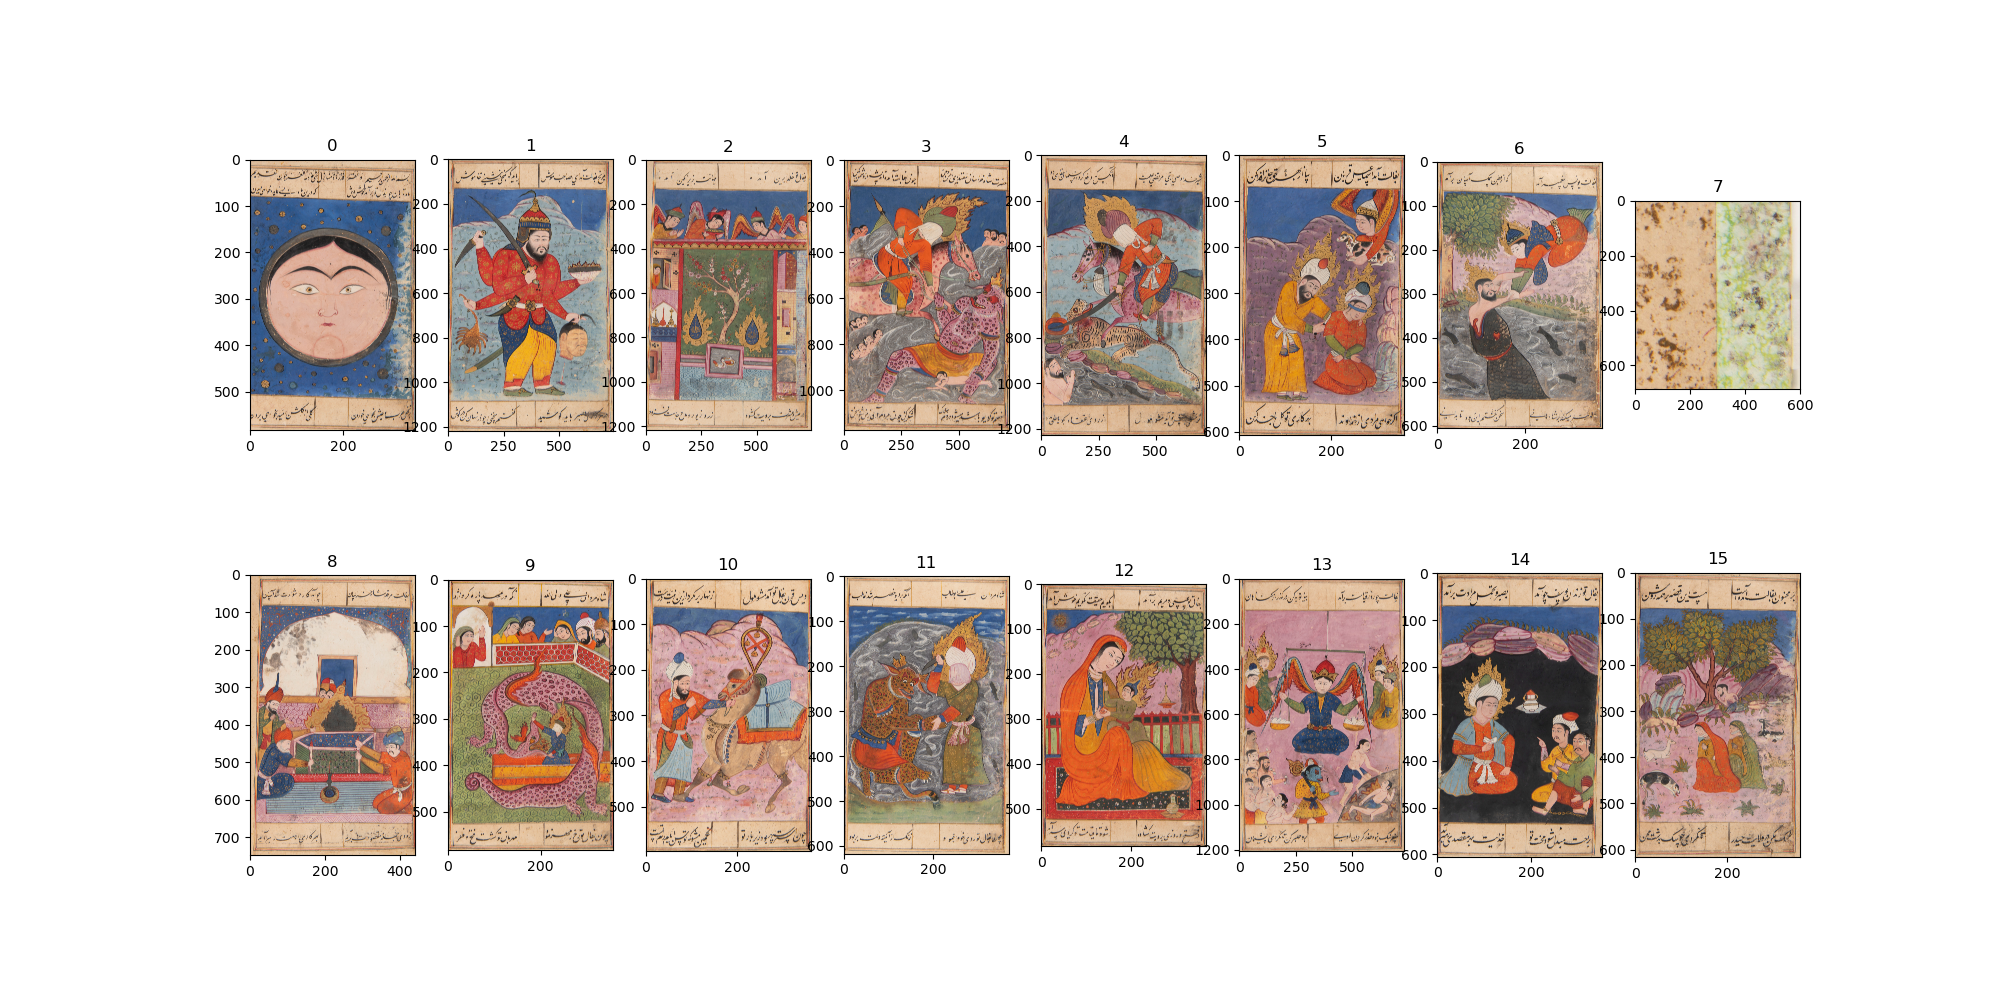

In [8]:
fig, axs = plt.subplots(ncols=8, nrows=2, figsize=[20, 10])
axs = axs.flatten()
for i, [im, ax, extent] in enumerate(zip(imvis_list, axs, extent_list)): 
    ax.imshow(im, extent=extent)
    ax.set_title(i)

In [ ]:
n = 0 
datastack_file = datastack_files[n]
ds = mx.DataStack(datastack_file)

cube = ds.read('maxrf_cube', compute=False)
imvis = ds.read('imvis_reg_highres')
extent = ds.read('imvis_extent')

In [10]:
ds.tree()

/
├── compton_peak_energy (1,) float64
├── hotmax_baselines (32, 4096) float64
├── hotmax_noiselines (32, 4096) float64
├── hotmax_peak_idxs_flat (33,) int64
├── hotmax_peak_idxs_list (32, 2) int64
├── hotmax_spectra (32, 4096) float32
├── hotmax_spots (32, 2) int64
├── hotmax_subpeak_idxs_list (32, 19) int64
├── imvis_extent (4,) int64
├── imvis_reg (583, 355, 3) uint8
├── imvis_reg_ (583, 355, 3) uint8
├── imvis_reg_highres (8256, 5027, 3) uint8
├── imvis_reg_highres_ (8256, 5027, 3) uint8
├── maxrf_cube (583, 355, 4096) float32
├── maxrf_energies (4096,) float64
├── maxrf_maxspectrum (4096,) float32
├── maxrf_sumspectrum (4096,) float64
├── nmf_atomnums (18,) int64
├── nmf_elementmaps (18, 583, 355) float32
├── nmf_gausscomponents (34, 4096) float32
├── nmf_peakmaps (34, 583, 355) float32
└── nmf_peaks2elements_matrix (18, 33) float32

/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-01_400_600_50.datastack:




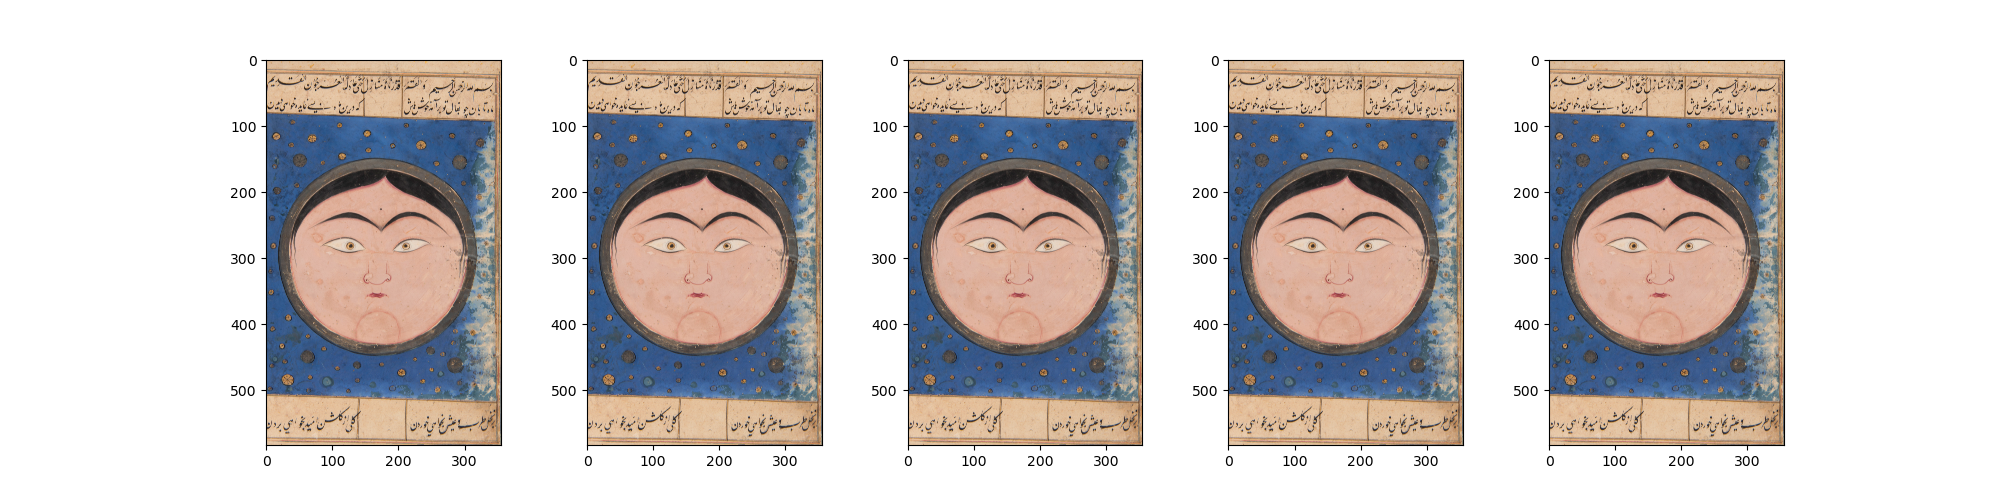

In [11]:
fig, axs = plt.subplots(ncols=5, figsize=[20, 5])
axs = axs.flatten() 

for ax in axs: 
    ax.imshow(imvis, extent=extent)

In [12]:
xylims_list = [[int(ax.get_xlim()[0]), int(ax.get_xlim()[1]), int(ax.get_ylim()[0]), int(ax.get_ylim()[1])] for ax in axs]
xylims_list 

[[184, 198, 110, 95],
 [204, 234, 346, 307],
 [229, 237, 132, 125],
 [221, 232, 172, 163],
 [158, 184, 71, 48]]

In [17]:
cube_rois = [cube[l:k, i:j].compute() for i, j, k, l in xylims_list]

In [ ]:
c = cube_rois

In [ ]:
y_mean_list = [cr.mean(a)]

In [16]:
fig, axs = plt.subplots(nrows=len(xylims_list), figsize=[20, 10])
axs = axs.flatten() 

for ax in axs: 
    ax.plot

[<bound method DaskMethodsMixin.compute of dask.array<getitem, shape=(15, 14, 4096), dtype=float32, chunksize=(15, 14, 410), chunktype=numpy.ndarray>>,
 <bound method DaskMethodsMixin.compute of dask.array<getitem, shape=(39, 30, 4096), dtype=float32, chunksize=(39, 30, 410), chunktype=numpy.ndarray>>,
 <bound method DaskMethodsMixin.compute of dask.array<getitem, shape=(7, 8, 4096), dtype=float32, chunksize=(7, 8, 410), chunktype=numpy.ndarray>>,
 <bound method DaskMethodsMixin.compute of dask.array<getitem, shape=(9, 11, 4096), dtype=float32, chunksize=(9, 11, 410), chunktype=numpy.ndarray>>,
 <bound method DaskMethodsMixin.compute of dask.array<getitem, shape=(23, 26, 4096), dtype=float32, chunksize=(23, 20, 410), chunktype=numpy.ndarray>>]

%pip install notebook